# 04 - Synthetic Control Case Study

Builds a counterfactual for one treated state as a weighted blend of
never-treated donor states, with weights constrained to the simplex
(non-negative, summing to one) so the counterfactual cannot extrapolate
outside the donors' observed range. In the tradition of Abadie, Diamond &
Hainmueller (2010) and Card & Krueger's NJ/PA study.

`src/methods/synthetic_control.py` implements this on scipy - no R, no
`Synth` package.


In [ ]:
import sys
from pathlib import Path

# Walk up to the project root so the notebook runs from any working directory.
root = next(p for p in Path.cwd().resolve().parents if (p / "src").is_dir())
sys.path.insert(0, str(root))
# Data vintage: which raw inputs produced everything below. LAUS is
# revised, so an executed notebook has to carry its own provenance.
from src.data.manifest import format_manifest

print(format_manifest())


In [2]:
from src.data.loader import load_state_year_panel
from src.methods.synthetic_control import estimate_synthetic_control

panel, is_synthetic = load_state_year_panel()
never_treated = sorted(panel[panel.adoption_year.isna()].state.unique())
print(f"panel: {'synthetic' if is_synthetic else 'real'}, {len(panel)} rows")
print(f'donor pool ({len(never_treated)} never-treated): {", ".join(never_treated)}')

panel: real, 1173 rows
donor pool (14 never-treated): AL, GA, ID, IN, KS, LA, MS, ND, OK, SC, TN, TX, UT, WY


## Picking a case study

A case study needs a decent pre-period. We take the adopter with the most
pre-treatment years, breaking ties alphabetically.

In [3]:
first_year = int(panel.year.min())
adopters = (panel.dropna(subset=['adoption_year'])
            .drop_duplicates('state')
            .set_index('state').adoption_year.astype(int))
eligible = adopters[adopters > first_year + 2].sort_values()

treated_state = str(eligible.index[0])
treatment_year = int(eligible.iloc[0])
print(f'case study: {treated_state}, adopted {treatment_year} '
      f'({treatment_year - first_year} pre-treatment years)')

case study: IL, adopted 2004 (4 pre-treatment years)


In [4]:
fit = estimate_synthetic_control(
    panel, treated_state, treatment_year, donors=never_treated
)
print(f"pre-treatment RMSPE:  {fit['pre_rmspe']:.4f}")
print(f"post-treatment RMSPE: {fit['post_rmspe']:.4f}")
print(f"post/pre ratio:       {fit['rmspe_ratio']:.2f}")

pre-treatment RMSPE:  0.2075
post-treatment RMSPE: 0.8809
post/pre ratio:       4.25


Pre-treatment RMSPE is the fit-quality guard. If the synthetic control
never tracked the state before treatment, the post-treatment gap is not
an effect estimate.

In [5]:
weights = fit['weights']
weights[weights > 0.001].rename('weight').to_frame()

,weight
MS,0.356391
SC,0.343487
TX,0.300122


## Actual vs. synthetic

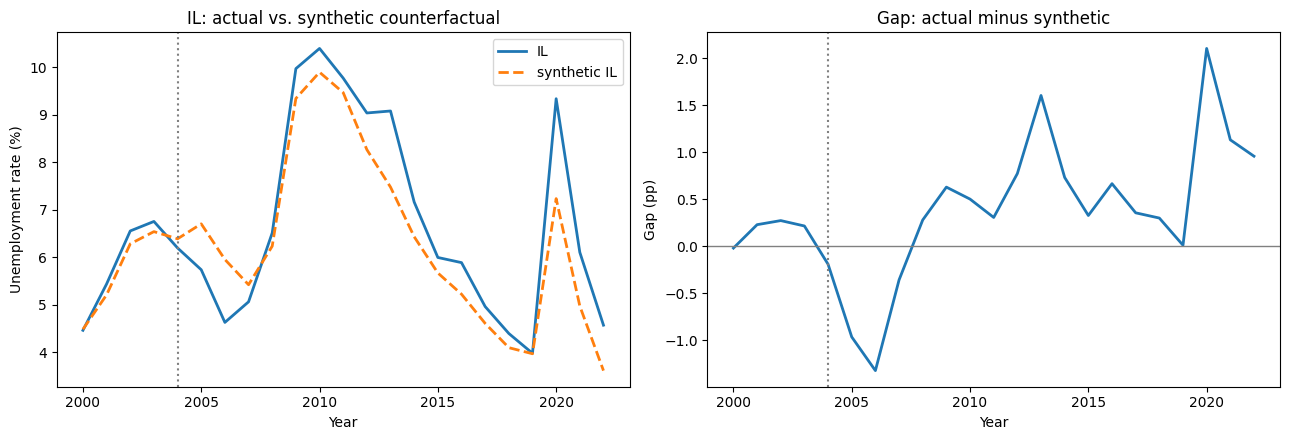

In [6]:
import matplotlib.pyplot as plt

paths = fit['paths']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

actual = paths[paths.type == 'actual']
synth = paths[paths.type == 'synthetic']
ax1.plot(actual.year, actual.unemployment_rate, label=treated_state, linewidth=2)
ax1.plot(synth.year, synth.unemployment_rate, '--',
         label=f'synthetic {treated_state}', linewidth=2)
ax1.axvline(treatment_year, color='gray', linestyle=':')
ax1.set_xlabel('Year'); ax1.set_ylabel('Unemployment rate (%)')
ax1.set_title(f'{treated_state}: actual vs. synthetic counterfactual')
ax1.legend()

gaps = fit['gaps']
ax2.plot(gaps.index, gaps.values, linewidth=2)
ax2.axhline(0, color='gray', linewidth=1)
ax2.axvline(treatment_year, color='gray', linestyle=':')
ax2.set_xlabel('Year'); ax2.set_ylabel('Gap (pp)')
ax2.set_title('Gap: actual minus synthetic')

plt.tight_layout()
plt.show()

## Permutation inference

There is one treated unit, so classical standard errors do not apply.
Abadie et al. instead refit the whole procedure pretending each donor was
treated, then rank the real state's post/pre RMSPE ratio against that
distribution. Donors the method fits badly before treatment blow up the
ratio for reasons unrelated to any effect, so `pre_rmspe_cutoff` drops
them from the ranking.

In [7]:
from src.methods.synthetic_control import placebo_test

placebos, p_value = placebo_test(
    panel, treated_state, treatment_year,
    donors=never_treated, pre_rmspe_cutoff=5.0,
)
print(f'p-value (rank among {int(placebos.included.sum())} included units): {p_value:.3f}')
placebos.head(10)

p-value (rank among 15 included units): 0.867


,unit,pre_rmspe,post_rmspe,rmspe_ratio,is_treated,included
0,AL,3.233716e-09,0.847620,2.621194e+08,False,True
1,KS,5.049219e-08,0.519749,1.029365e+07,False,True
2,TN,1.066157e-07,0.834013,7.822616e+06,False,True
3,GA,3.514835e-02,2.328652,6.625210e+01,False,True
4,ID,5.980621e-02,1.418960,2.372596e+01,False,True
5,IN,1.222192e-01,2.046551,1.674492e+01,False,True
6,UT,1.106054e-01,1.780828,1.610073e+01,False,True
7,LA,1.941921e-01,1.402402,7.221724e+00,False,True
8,TX,2.149867e-01,1.538035,7.154097e+00,False,True
9,WY,1.335326e-01,0.930089,6.965257e+00,False,True


## Averaging over every adopter

A single case study estimates one state's ATT, not the average one.
`aggregate_synthetic_control` fits a separate synthetic control for every
staggered adopter against the never-treated donor pool and averages the
post-treatment gaps, which is what makes this method comparable to the
panel-wide estimators in notebook 05.

In [8]:
from src.methods.synthetic_control import aggregate_synthetic_control

agg = aggregate_synthetic_control(panel, n_boot=500, seed=0)
print(f"ATT across {agg['n_units']} adopters vs {agg['n_donors']} donors: "
      f"{agg['att']:+.4f} pp")
print(f"95% CI: [{agg['ci_lower']:+.4f}, {agg['ci_upper']:+.4f}]")
agg['effects']

ATT across 25 adopters vs 14 donors: +0.5715 pp
95% CI: [+0.2792, +0.8639]


,state,adoption_year,effect,pre_rmspe,n_post
0,SD,2015,-0.292206,0.267649,8
1,MT,2007,-0.249584,0.278129,16
2,NE,2015,-0.158391,0.152507,8
3,IA,2007,0.001288,0.174128,16
4,MN,2005,0.022756,0.029909,18
5,MD,2007,0.082934,0.101185,16
6,AR,2006,0.158411,0.033294,17
7,VA,2021,0.176617,0.413262,2
8,PA,2007,0.182590,0.046032,16
9,WV,2006,0.189498,0.339827,17
